In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from LIF_model import LIF

In [2]:
dt = 1e-3
T = 1
neuron = LIF(dt=dt)

In [3]:
time = np.arange(0, T, dt)

In [4]:
image = cv2.imread("lapin_adam.jpg", cv2.IMREAD_GRAYSCALE)

In [5]:
image = image / 255.0

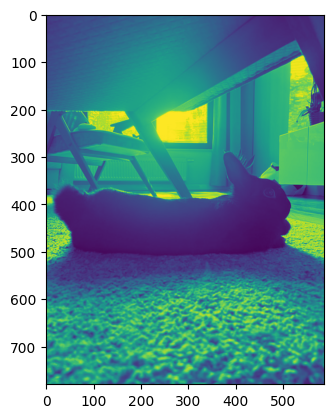

In [6]:
plt.imshow(image)

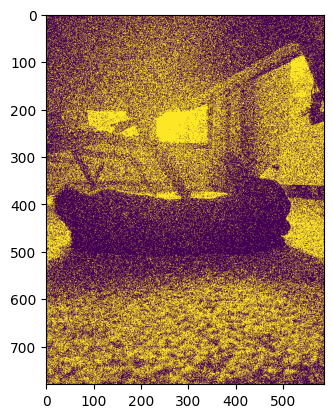

In [62]:
def get_spike_image(image, r_max=1000):

    image_spike = np.zeros((image.shape[0], image.shape[1]))

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):

            spike_probability = image[i, j] * r_max * dt
            image_spike[i, j] = 1 if np.random.rand() < spike_probability else 0
    
    return image_spike

image_spike = get_spike_image(image, r_max=1000)
plt.figure()
plt.imshow(image_spike)

In [33]:
def get_neurones_number(H, W, strides, padding, K_h, K_w, filters):

    H_out = ((H + 2 * padding - K_h) / strides) + 1
    W_out = ((W + 2 * padding - K_w) / strides) + 1

    return H_out * W_out * filters

In [39]:
neurons = get_neurones_number(image.shape[1], image.shape[0], 2, 0, 215, 215, 1)
print(neurons)
print(image.shape)

52872.75
(780, 586)
